In [2]:
import pandas as pd

In [23]:
from pathlib import Path
from zipfile import ZipFile
import csv
import io

data_dir = Path(r"C:\Users\user\Documents\LAB\kci\data")
output_path = Path(r"C:\Users\user\Documents\LAB\kci\따릉이데이터_2025.csv")

zip_files = sorted(data_dir.glob("tpss_bcycl_od_statnhm_2025??.zip"))

rename_map = {
    "전체_건수": "전체건수",
    "기준_시간대": "기준_시간",
    "시작_대여소": "시작_대여소명",
    "종료_대여소": "종료_대여소명",
}

expected_columns = None

with output_path.open(
    "w",
    encoding="utf-8-sig",
    newline="",
) as output_file:

    writer = csv.writer(output_file, lineterminator="\n")

    for zip_path in zip_files:
        print(f"{zip_path.name} 병합 시작")

        with ZipFile(zip_path) as zip_file:
            csv_files = sorted(
                name for name in zip_file.namelist()
                if name.lower().endswith(".csv")
            )

            for csv_name in csv_files:
                with zip_file.open(csv_name) as raw_file:
                    # 헤더를 이용해 파일별 인코딩 판별
                    header_bytes = raw_file.readline()

                    try:
                        header_text = header_bytes.decode("utf-8-sig")
                        encoding = "utf-8"
                    except UnicodeDecodeError:
                        header_text = header_bytes.decode("cp949")
                        encoding = "cp949"

                    original_columns = next(csv.reader([header_text]))

                    columns = [
                        rename_map.get(column, column)
                        for column in original_columns
                    ]

                    if expected_columns is None:
                        expected_columns = columns
                        writer.writerow(columns)
                    elif columns != expected_columns:
                        raise ValueError(
                            f"열 구성이 다릅니다: {csv_name}"
                        )

                    # 이미 헤더를 읽었으므로 나머지 데이터만 병합
                    with io.TextIOWrapper(
                        raw_file,
                        encoding=encoding,
                        newline="",
                    ) as input_file:

                        last_character = "\n"

                        while True:
                            text = input_file.read(1024 * 1024)

                            if not text:
                                break

                            output_file.write(text)
                            last_character = text[-1]

                        if last_character not in "\r\n":
                            output_file.write("\n")

        print(f"{zip_path.name} 병합 완료")

print(f"최종 파일: {output_path}")

tpss_bcycl_od_statnhm_202501.zip 병합 시작
tpss_bcycl_od_statnhm_202501.zip 병합 완료
tpss_bcycl_od_statnhm_202502.zip 병합 시작
tpss_bcycl_od_statnhm_202502.zip 병합 완료
tpss_bcycl_od_statnhm_202503.zip 병합 시작
tpss_bcycl_od_statnhm_202503.zip 병합 완료
tpss_bcycl_od_statnhm_202504.zip 병합 시작
tpss_bcycl_od_statnhm_202504.zip 병합 완료
tpss_bcycl_od_statnhm_202505.zip 병합 시작
tpss_bcycl_od_statnhm_202505.zip 병합 완료
tpss_bcycl_od_statnhm_202506.zip 병합 시작
tpss_bcycl_od_statnhm_202506.zip 병합 완료
tpss_bcycl_od_statnhm_202507.zip 병합 시작
tpss_bcycl_od_statnhm_202507.zip 병합 완료
tpss_bcycl_od_statnhm_202508.zip 병합 시작
tpss_bcycl_od_statnhm_202508.zip 병합 완료
tpss_bcycl_od_statnhm_202509.zip 병합 시작
tpss_bcycl_od_statnhm_202509.zip 병합 완료
tpss_bcycl_od_statnhm_202510.zip 병합 시작
tpss_bcycl_od_statnhm_202510.zip 병합 완료
tpss_bcycl_od_statnhm_202511.zip 병합 시작
tpss_bcycl_od_statnhm_202511.zip 병합 완료
tpss_bcycl_od_statnhm_202512.zip 병합 시작
tpss_bcycl_od_statnhm_202512.zip 병합 완료
최종 파일: C:\Users\user\Documents\LAB\kci\따릉이데이터_2025.csv


In [53]:
import pandas as pd

In [54]:
df = pd.read_csv(r'C:\Users\user\Documents\LAB\kci\따릉이데이터_2025.csv')

In [55]:
df.head()

,기준_날짜,집계_기준,기준_시간,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체건수,전체_이용_분,전체_이용_거리
0,20250109,출발시간,1950,ST-2056,발산1동_035_2,ST-1064,발산1동_056_1,1,4.0,680.0
1,20250109,출발시간,930,ST-1474,공릉1동_031_1,ST-3060,공릉2동_050_1,1,8.0,1240.0
2,20250109,출발시간,2050,ST-717,중앙동_028_1,ST-725,은천동_022_1,1,8.0,1105.0
3,20250109,출발시간,1615,ST-3017,합정동_025_1,ST-8,합정동_023_2,1,5.0,735.0
4,20250109,출발시간,2200,ST-158,이화동_009_1,ST-159,"종로5,6가동_002_1",1,7.0,652.0


In [56]:
df.shape

(68023993, 10)

In [57]:
df["기준_날짜"] = (
    pd.to_datetime(df["기준_날짜"].astype(str))
      .dt.normalize()
)

In [58]:
# 날짜 형식 및 시간을 00:00:00으로 통일
dates = pd.to_datetime(df["기준_날짜"], errors="coerce").dt.normalize()

# 2025년 전체 날짜
all_dates_2025 = pd.date_range("2025-01-01", "2025-12-31", freq="D")

# df에 없는 날짜
missing_dates = all_dates_2025.difference(dates.dropna().unique())  

print("없는 날짜 수:", len(missing_dates))
display(pd.DataFrame({
    "없는_날짜": missing_dates,
    "날짜_문자열": missing_dates.strftime("%Y%m%d")
}))

없는 날짜 수: 10


,없는_날짜,날짜_문자열
0,2025-01-01,20250101
1,2025-01-02,20250102
2,2025-01-03,20250103
3,2025-01-04,20250104
4,2025-01-05,20250105
5,2025-01-06,20250106
6,2025-01-07,20250107
7,2025-01-08,20250108
8,2025-07-01,20250701
9,2025-07-02,20250702


In [59]:
pack = pd.read_csv(r'C:\Users\user\Documents\LAB\kci\data\서울시 공공자전거 따릉이 대여소 마스터 정보.csv' , encoding='cp949')

In [60]:
pack.head()

,대여소_ID,주소1,주소2,위도,경도
0,ST-999,서울특별시 양천구 목동서로 280,목동아파트 8단지 상가동,0.000000,0.000000
1,ST-998,서울특별시 양천구 목동서로 130,목동아파트 4단지 상가동,0.000000,0.000000
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323


In [61]:
# 위도 또는 경도가 NaN이거나 0인 행
invalid_pack = pack[
    pack[["위도", "경도"]].isna().any(axis=1)
    | pack[["위도", "경도"]].eq(0).any(axis=1)
]

display(invalid_pack)
print("해당 행 수:", len(invalid_pack))

,대여소_ID,주소1,주소2,위도,경도
0,ST-999,서울특별시 양천구 목동서로 280,목동아파트 8단지 상가동,0.0,0.0
1,ST-998,서울특별시 양천구 목동서로 130,목동아파트 4단지 상가동,0.0,0.0
11,ST-989,서울특별시 마포구 월드컵로5길 11,합정동 주민센터,0.0,0.0
156,ST-858,서울특별시 강북구 덕릉로40길 48,번동 619-53,0.0,0.0
171,ST-844,서울특별시 성북구 인촌로 16,성북구 안암동2가 140-1,0.0,0.0
...,...,...,...,...,...
3353,ST-1060,서울특별시 강동구 둔촌동 산 125,일자산 체육관,0.0,0.0
3386,ST-1030,서울특별시 은평구 녹번동 141-92,유성빌딩 옆,0.0,0.0
3394,ST-1022,서울특별시 은평구 진관동 2-6,입곡삼거리,0.0,0.0
3409,ST-1009,서울특별시 양천구 신월동 263,신월 청소년 문화센터,0.0,0.0


해당 행 수: 77


In [62]:
point = pd.read_excel(r'C:\Users\user\Documents\LAB\kci\data\공공자전거 대여소 정보(25.12월 기준).xlsx')

In [63]:
point.head()

,대여소\n번호,Unnamed: 1,자치구,Unnamed: 3,위도,경도
0,102,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629
1,103,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835
2,104,합정역 1번출구 앞,마포구,서울특별시 마포구 양화로 59,37.550629,126.914986
3,105,합정역 5번출구 앞,마포구,서울특별시 마포구 양화로 48,37.550007,126.914825
4,106,합정역 7번출구 앞,마포구,서울특별시 마포구 독막로 4,37.548645,126.912827


In [64]:
point = point.drop(columns=['대여소\n번호', '자치구']).rename(columns={'Unnamed: 1' : '보관소명' , 'Unnamed: 3': '보관소 주소'})

In [65]:
point.head()

,보관소명,보관소 주소,위도,경도
0,망원역 1번출구 앞,서울특별시 마포구 월드컵로 72,37.555649,126.910629
1,망원역 2번출구 앞,서울특별시 마포구 월드컵로 79,37.554951,126.910835
2,합정역 1번출구 앞,서울특별시 마포구 양화로 59,37.550629,126.914986
3,합정역 5번출구 앞,서울특별시 마포구 양화로 48,37.550007,126.914825
4,합정역 7번출구 앞,서울특별시 마포구 독막로 4,37.548645,126.912827


In [66]:
# 주소 비교용 좌표 조회표 생성
point_coord = point.copy()

point_coord["주소키"] = (
    point_coord["보관소 주소"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

coord_map = (
    point_coord[
        point_coord["위도"].notna()
        & point_coord["경도"].notna()
        & point_coord["위도"].ne(0)
        & point_coord["경도"].ne(0)
    ]
    .drop_duplicates("주소키")
    .set_index("주소키")[["위도", "경도"]]
)

# pack의 주소 정리
pack["주소키"] = (
    pack["주소1"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# pack의 NaN 또는 0인 좌표만 채우기
for column in ["위도", "경도"]:
    invalid = pack[column].isna() | pack[column].eq(0)

    pack.loc[invalid, column] = (
        pack.loc[invalid, "주소키"].map(coord_map[column])
    )

pack.drop(columns="주소키", inplace=True)

display(pack)

,대여소_ID,주소1,주소2,위도,경도
0,ST-999,서울특별시 양천구 목동서로 280,목동아파트 8단지 상가동,NaN,NaN
1,ST-998,서울특별시 양천구 목동서로 130,목동아파트 4단지 상가동,NaN,NaN
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323
...,...,...,...,...,...
3416,ST-1002,서울특별시 양천구 목동동로 316-6,서울시 도로환경관리센터,37.529900,126.876541
3417,ST-1001,서울특별시 양천구 남부순환로4길20,서서울호수공원,NaN,NaN
3418,ST-1000,서울특별시 양천구 신정동 236,서부식자재마트 건너편,37.510380,126.866798
3419,ST-100,서울특별시 광진구 아차산로 262,더샵스타시티 C동 앞,37.536667,127.073593


In [67]:
# 열 이름의 숨은 공백 제거
point.columns = (
    point.columns.astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

# point의 보관소명별 좌표 조회표 생성
point_coord = point.copy()

point_coord["보관소명키"] = (
    point_coord["보관소명"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

coord_map = (
    point_coord[
        point_coord["위도"].notna()
        & point_coord["경도"].notna()
        & point_coord["위도"].ne(0)
        & point_coord["경도"].ne(0)
    ]
    .drop_duplicates("보관소명키")
    .set_index("보관소명키")[["위도", "경도"]]
)

# pack의 주소2와 point의 보관소명 매칭
pack["보관소명키"] = (
    pack["주소2"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# pack에서 아직 NaN 또는 0인 좌표만 채우기
for column in ["위도", "경도"]:
    invalid = pack[column].isna() | pack[column].eq(0)

    pack.loc[invalid, column] = (
        pack.loc[invalid, "보관소명키"]
        .map(coord_map[column])
    )

pack.drop(columns="보관소명키", inplace=True)

display(pack)

,대여소_ID,주소1,주소2,위도,경도
0,ST-999,서울특별시 양천구 목동서로 280,목동아파트 8단지 상가동,NaN,NaN
1,ST-998,서울특별시 양천구 목동서로 130,목동아파트 4단지 상가동,NaN,NaN
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323
...,...,...,...,...,...
3416,ST-1002,서울특별시 양천구 목동동로 316-6,서울시 도로환경관리센터,37.529900,126.876541
3417,ST-1001,서울특별시 양천구 남부순환로4길20,서서울호수공원,NaN,NaN
3418,ST-1000,서울특별시 양천구 신정동 236,서부식자재마트 건너편,37.510380,126.866798
3419,ST-100,서울특별시 광진구 아차산로 262,더샵스타시티 C동 앞,37.536667,127.073593


In [68]:
unmatched_pack = pack[
    pack[["위도", "경도"]].isna().any(axis=1)
    | pack[["위도", "경도"]].eq(0).any(axis=1)
].copy()

display(unmatched_pack)
print("매핑되지 않은 행 수:", len(unmatched_pack))

,대여소_ID,주소1,주소2,위도,경도
0,ST-999,서울특별시 양천구 목동서로 280,목동아파트 8단지 상가동,NaN,NaN
1,ST-998,서울특별시 양천구 목동서로 130,목동아파트 4단지 상가동,NaN,NaN
11,ST-989,서울특별시 마포구 월드컵로5길 11,합정동 주민센터,NaN,NaN
156,ST-858,서울특별시 강북구 덕릉로40길 48,번동 619-53,NaN,NaN
171,ST-844,서울특별시 성북구 인촌로 16,성북구 안암동2가 140-1,NaN,NaN
...,...,...,...,...,...
3347,ST-1066,서울특별시 강서구 내발산동 741-8,마곡수명산파크2단지 교차로,NaN,NaN
3353,ST-1060,서울특별시 강동구 둔촌동 산 125,일자산 체육관,NaN,NaN
3386,ST-1030,서울특별시 은평구 녹번동 141-92,유성빌딩 옆,NaN,NaN
3394,ST-1022,서울특별시 은평구 진관동 2-6,입곡삼거리,NaN,NaN


매핑되지 않은 행 수: 69


In [69]:
import pandas as pd

# 서울시 경계

좌표계: EPSG:5186
행 개수: 467
['EMD_CD', 'COL_ADM_SE', 'EMD_NM', 'SGG_OID', 'geometry']


,EMD_CD,COL_ADM_SE,EMD_NM,SGG_OID,geometry
0,11110101,11110,청운동,1036,"POLYGON ((196593.774 554114.361, 196611.342 55..."
1,11110102,11110,신교동,307,"POLYGON ((196912.513 554003.597, 196920.988 55..."
2,11110103,11110,궁정동,1034,"POLYGON ((197377.934 553847.046, 197388.359 55..."
3,11110104,11110,효자동,309,"POLYGON ((197664.978 553742.317, 197663.825 55..."
4,11110105,11110,창성동,316,"POLYGON ((197662.098 553585.836, 197662.501 55..."


<Axes: >

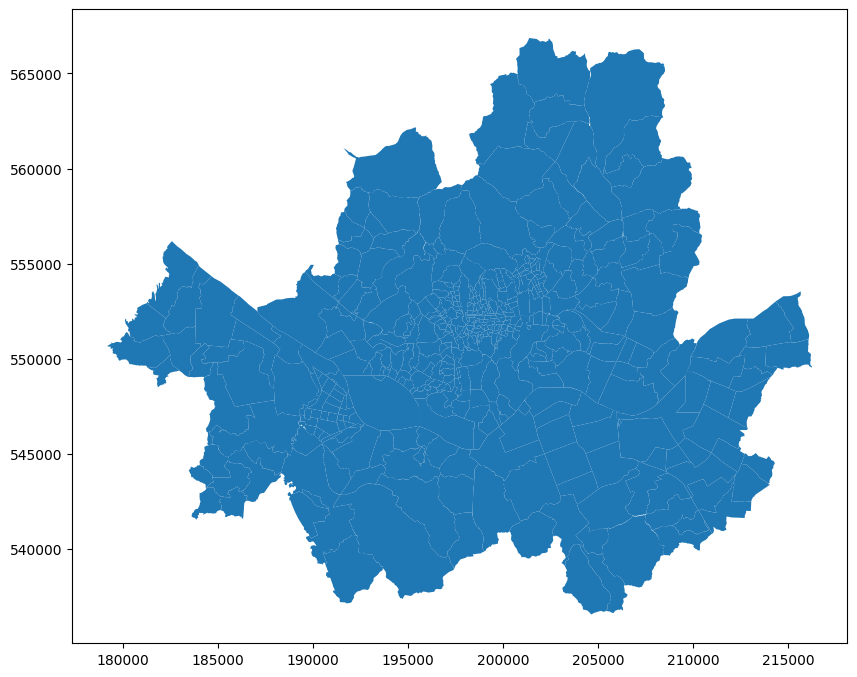

In [71]:
import geopandas as gpd

shp_path = (
    r"C:\Users\user\Documents\LAB\kci\data\서울시 경계 데이터"
    r"\admstr_zone_lgldong_bndry_24.shp"
)

seoul = gpd.read_file(
    shp_path,
    encoding="EUC-KR"
)

print("좌표계:", seoul.crs)
print("행 개수:", len(seoul))
print(seoul.columns.tolist())

display(seoul.head())
seoul.plot(figsize=(10, 10))

,geometry,EMD_CD,COL_ADM_SE,EMD_NM,SGG_OID
0,"POLYGON ((189724.774 540660.326, 189737.044 54...",11110101,11110,청운동,1036


<Axes: >

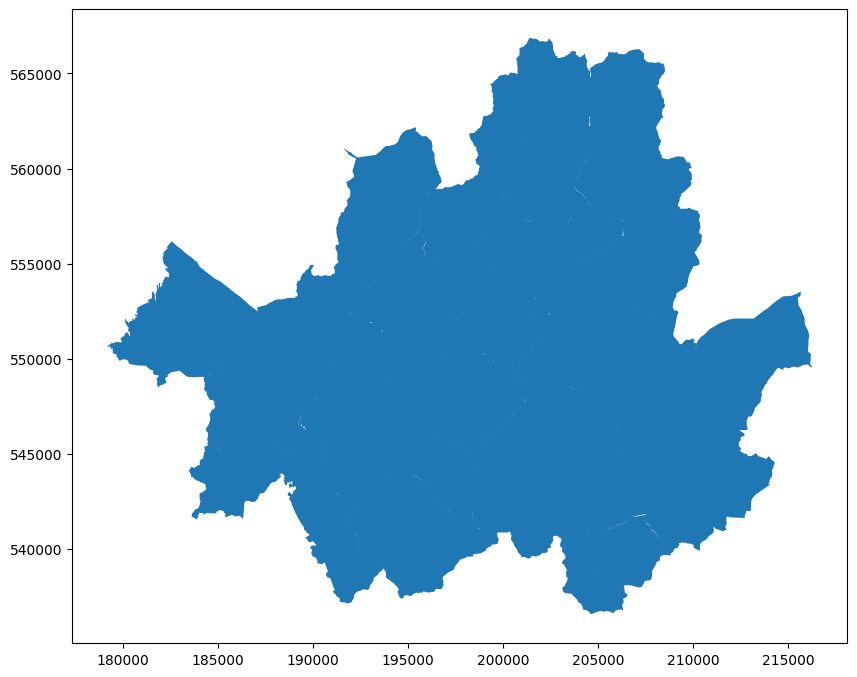

In [72]:
seoul_boundary = seoul.dissolve().reset_index(drop=True)

display(seoul_boundary)
seoul_boundary.plot(figsize=(10, 10))

In [73]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box

grid_size = 100  # 100m

# 서울 경계를 하나의 도형으로 합치기
seoul_boundary = seoul.to_crs("EPSG:5186").dissolve()
seoul_geom = seoul_boundary.geometry.iloc[0]

# 서울 경계를 포함하는 좌표 범위
minx, miny, maxx, maxy = seoul_geom.bounds

# 격자 시작점을 100m 단위로 정렬
minx = np.floor(minx / grid_size) * grid_size
miny = np.floor(miny / grid_size) * grid_size
maxx = np.ceil(maxx / grid_size) * grid_size
maxy = np.ceil(maxy / grid_size) * grid_size

x_values = np.arange(minx, maxx, grid_size)
y_values = np.arange(miny, maxy, grid_size)

# 100m × 100m 격자 생성
grid_data = []

for row, y in enumerate(y_values):
    for col, x in enumerate(x_values):
        grid_data.append({
            "grid_id": f"G{row:04d}_{col:04d}",
            "grid_x": x,
            "grid_y": y,
            "geometry": box(
                x,
                y,
                x + grid_size,
                y + grid_size
            )
        })

grid_100m = gpd.GeoDataFrame(
    grid_data,
    geometry="geometry",
    crs="EPSG:5186"
)

# 서울시 경계와 겹치는 격자만 선택
grid_100m = grid_100m[
    grid_100m.intersects(seoul_geom)
].copy()

grid_100m.reset_index(drop=True, inplace=True)

print("생성된 격자 수:", len(grid_100m))
display(grid_100m.head())

생성된 격자 수: 61714


,grid_id,grid_x,grid_y,geometry
0,G0000_0254,204500.0,536500.0,"POLYGON ((204600 536500, 204600 536600, 204500..."
1,G0000_0255,204600.0,536500.0,"POLYGON ((204700 536500, 204700 536600, 204600..."
2,G0000_0256,204700.0,536500.0,"POLYGON ((204800 536500, 204800 536600, 204700..."
3,G0001_0253,204400.0,536600.0,"POLYGON ((204500 536600, 204500 536700, 204400..."
4,G0001_0254,204500.0,536600.0,"POLYGON ((204600 536600, 204600 536700, 204500..."


<Axes: >

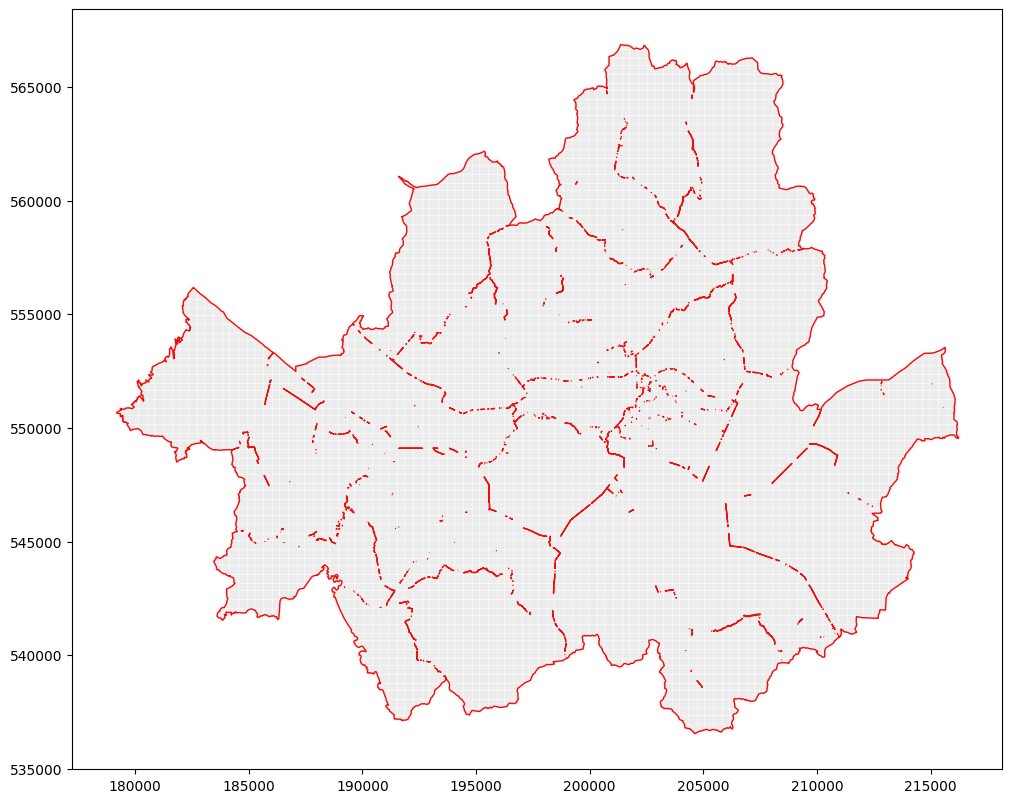

In [74]:
ax = seoul_boundary.boundary.plot(
    figsize=(12, 12),
    color="red",
    linewidth=1
)

grid_100m.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.05
)

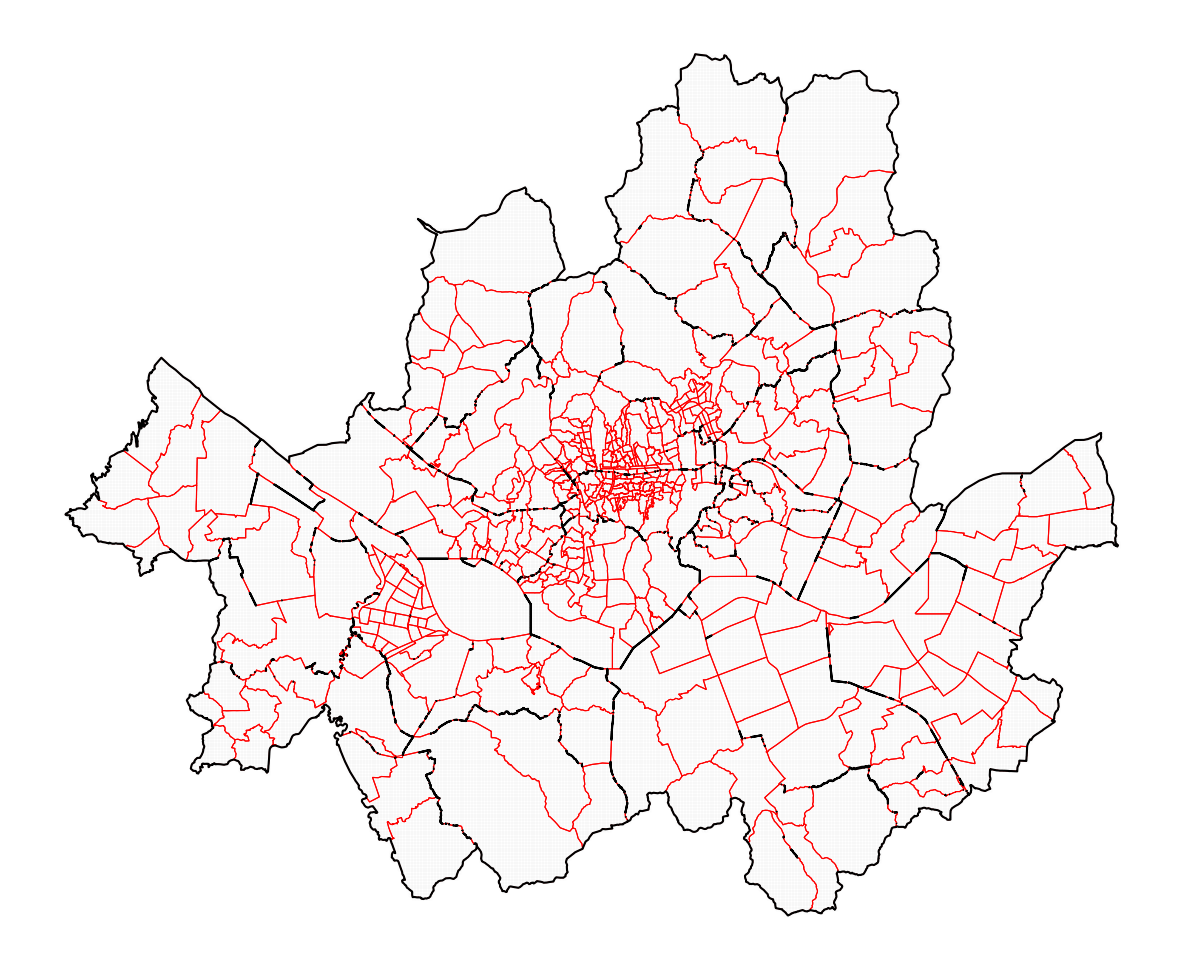

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

# 100m 격자
grid_100m.boundary.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.05,
    zorder=1
)

# 동별 경계를 가장 위에 표시
seoul.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.8,
    zorder=2
)

# 서울시 외곽 경계
seoul_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
    zorder=3
)

ax.set_axis_off()
plt.show()